<a href="https://colab.research.google.com/github/swethaukkarde/Neural-networks-and-deep-learning/blob/main/Exp_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--2026-04-10 06:47:14--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 104.21.88.156, 172.67.185.199, 2606:4700:3037::6815:589c, ...
Connecting to pjreddie.com (pjreddie.com)|104.21.88.156|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://data.pjreddie.com/files/yolov3.weights [following]
--2026-04-10 06:47:14--  https://data.pjreddie.com/files/yolov3.weights
Resolving data.pjreddie.com (data.pjreddie.com)... 172.67.185.199, 104.21.88.156, 2606:4700:3037::6815:589c, ...
Connecting to data.pjreddie.com (data.pjreddie.com)|172.67.185.199|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248007048 (237M) [application/octet-stream]
Saving to: ‘yolov3.weights’

yolov3.weights      100%[===================>] 236.52M  68.7MB/s    in 3.4s    

2026-04-10 06:47:18 (68.9 MB/s) - ‘yolov3.weights’ saved [248007048/248007048]

--2026-04-10 06:47:18--  https://raw.githubusercontent.com

Saving traffic_nndl.jpeg to traffic_nndl.jpeg


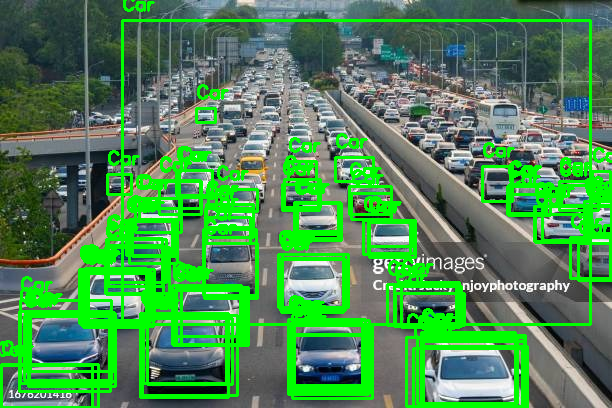

In [1]:
# Problem Statement:
# A smart parking system wants to detect cars entering and leaving the gate.
# Implement object detection using CNNs and show how bounding boxes help
# in locating each vehicle.

#exp 7

# -------------------------------
# Step 1: Download YOLO files
# -------------------------------
!wget https://pjreddie.com/media/files/yolov3.weights
!wget https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg
!wget https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names

# -------------------------------
# Step 2: Import libraries
# -------------------------------
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# -------------------------------
# Step 3: Load YOLO model
# -------------------------------
net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")

# Load class names
with open("coco.names", "r") as f:
    classes = f.read().strip().split("\n")

# -------------------------------
# Step 4: Upload Image
# -------------------------------
from google.colab import files
uploaded = files.upload()

# Get image name
img_name = list(uploaded.keys())[0]
img = cv2.imread(img_name)
h, w = img.shape[:2]

# -------------------------------
# Step 5: Detection
# -------------------------------
blob = cv2.dnn.blobFromImage(img, 0.00392, (416,416), (0,0,0), True)
net.setInput(blob)

outs = net.forward(net.getUnconnectedOutLayersNames())

# -------------------------------
# Step 6: Draw Bounding Boxes
# -------------------------------
for out in outs:
    for det in out:
        scores = det[5:]
        class_id = np.argmax(scores)

        if classes[class_id] == "car" and scores[class_id] > 0.5:
            cx, cy, bw, bh = (det[0:4] * [w,h,w,h]).astype(int)
            x, y = int(cx - bw/2), int(cy - bh/2)

            cv2.rectangle(img, (x,y), (x+bw,y+bh), (0,255,0), 2)
            cv2.putText(img, "Car", (x,y-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

# -------------------------------
# Step 7: Show Output
# -------------------------------
cv2_imshow(img)